# How to train your potential

## Phase 1: Seed Data & Initial Training
In this part, we'll bootstrap the training of our initial MLP.
We build a random bulk structure from "solid" argon, and then rattle the positions randomly.
Based on this, we train two MLP's that will be used for our query-by-committee.

**Exercise!! Try to change the a_min and a_max to make the initial training set more diverse.**
Try for example values from 4 to 5.5. Does this more diverse dataset already make the initial MLP more stable in the simulation?

In [375]:
import numpy as np
from ase.build import bulk
from ase.calculators.lj import LennardJones
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.io import read, write
from ase import units, Atoms
from ase.visualize import view

import matplotlib.pyplot as plt

# Setup Data Generation Parameters
num_frames = 10  # How many unique configurations per dataset (50 total)
a_min, a_max = 4.8, 5.2  # Range for lattice parameter (equilibrium is ~5.0)
rattle_min, rattle_max = 0.01, 0.1  # Range for rattling standard deviation

def generate_rattled_dataset(num_frames, random_seed):
    """Generates a list of ASE Atoms objects with random volumes and rattling."""
    np.random.seed(random_seed)
    dataset = []
    
    for i in range(num_frames):
        # Randomize the volume (lattice parameter 'a')
        truth_calc = LennardJones(epsilon=0.0103, sigma=3.40)
        a_rand = np.random.uniform(a_min, a_max)
        atoms = bulk('Ar', crystalstructure='fcc', a=a_rand, cubic=True).repeat((3, 3, 3))
        
        # Rattle the atoms (simulate thermal displacement)
        stdev_rand = np.random.uniform(rattle_min, rattle_max)
        
        # fresh seed for each frame's rattle
        frame_rattle_seed = np.random.randint(0, 100000) 
        atoms.rattle(stdev=stdev_rand, seed=frame_rattle_seed)
        
        # Evaluate Ground Truth Physics
        atoms.calc = truth_calc
        atoms.get_potential_energy()  # Calculates and stores energy
        atoms.get_forces()            # Calculates and stores forces
        
        dataset.append(atoms)
        
    return dataset

# Generate the two independent datasets
print(f"Generating Set 1 ({num_frames} frames)...")
atoms_set_1 = generate_rattled_dataset(num_frames, random_seed=42)

print(f"Generating Set 2 ({num_frames} frames)...")
atoms_set_2 = generate_rattled_dataset(num_frames, random_seed=123)

# 3. Save to Extended XYZ format (required for MACE training)
write('seed_data_set_1.xyz', atoms_set_1, format='extxyz')
write('seed_data_set_2.xyz', atoms_set_2, format='extxyz')

print("Done! Check your directory for the new .xyz files.")

Generating Set 1 (10 frames)...
Generating Set 2 (10 frames)...
Done! Check your directory for the new .xyz files.


In [ ]:
view(atoms_set_1)

In [376]:
# Train Model 1. Using ! runs as a shell command instead
!rm -rf checkpoints logs results

!mace_run_train \
    --name="mace_model_1" \
    --train_file="seed_data_set_1.xyz" \
    --energy_key="energy" \
    --forces_key="forces" \
    --E0s="average" \
    --model="MACE" \
    --energy_weight=2.0 \
    --forces_weight=1.0 \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="16x0e" \
    --batch_size=5 \
    --max_num_epochs=50 \
    --r_max=5.0 \
    --seed=42 \
    --device=cpu

# Train Model 2. Using ! runs as a shell command instead
!mace_run_train \
    --name="mace_model_2" \
    --train_file="seed_data_set_2.xyz" \
    --energy_key="energy" \
    --forces_key="forces" \
    --E0s="average" \
    --model="MACE" \
    --energy_weight=50.0 \
    --forces_weight=1.0 \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="16x0e" \
    --batch_size=5 \
    --max_num_epochs=50 \
    --r_max=5.0 \
    --seed=35 \
    --device=cpu

!rm -rf checkpoints logs results


/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-06-03 03:10:43.069 INFO: ===========VERIFYING SETTINGS===========
2026-06-03 03:10:43.070 INFO: MACE version: 0.3.16
2026-06-03 03:10:43.070 INFO: Using CPU
2026-06-03 03:10:43.248 INFO: ===========LOADING INPUT DATA===========
2026-06-03 03:10:43.248 INFO: Using heads: ['Default']
2026-06-03 03:10:43.248 INFO: Using the key specifications to parse data:
2026-06-03 03:10:43.248 INFO: Default: KeySpecification(info_keys={'energy': 'energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head'

## Phase 2: Push it until it breaks
In this part, we'll perform an MD with our freshly trained MLP, but this time far above the gaseous point of argon!
What do you think of the MD statistics?

In [377]:
from mace.calculators import MACECalculator
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution


# Load the first MACE model
mace_calc = MACECalculator(model_paths="mace_model_1_compiled.model", device="cpu")

# Reset the atom box and attach MACE
test_atoms = bulk(
    'Ar',
    crystalstructure='fcc',
    a=5.00, 
    cubic=True).repeat((3, 3, 3))
test_atoms.calc = mace_calc
MaxwellBoltzmannDistribution(test_atoms, temperature_K=300)

# Setup MD at 300 K
md_fail = Langevin(
    test_atoms,
    timestep=2 * units.fs,
    temperature_K=300,
    friction=0.01
)

print("Running MACE at 300K.")
try:
    # We will log the max force to watch it blow up
    for step in range(500):
        md_fail.run(1)
        forces = test_atoms.get_forces()
        max_f = np.max(np.linalg.norm(forces, axis=1))
        temp = test_atoms.get_temperature()
        # Get Minimum Distance (ignoring self-interactions)
        distances = test_atoms.get_all_distances(mic=True)
        np.fill_diagonal(distances, np.inf) # Replace 0.0 on the diagonal with infinity
        min_dist = np.min(distances)
        
        print(f"Step {step:03d}: Temp = {temp:>6.2f} K | Max Force = {max_f:>6.2f} eV/A | Min Dist = {min_dist:>4.2f} Å")
except Exception as e:
    print(f"\nSimulation collapsed as expected! Error: {e}")

/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/mace/calculators/mace.py:226: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  torch.load(f=model_path, map_location=device)
/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/ase/md/langevin.py:110: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constrain

Running MACE at 300K.
Step 000: Temp = 355.14 K | Max Force =   0.02 eV/A | Min Dist = 3.51 Å
Step 001: Temp = 350.94 K | Max Force =   0.04 eV/A | Min Dist = 3.49 Å
Step 002: Temp = 349.81 K | Max Force =   0.06 eV/A | Min Dist = 3.46 Å
Step 003: Temp = 347.50 K | Max Force =   0.09 eV/A | Min Dist = 3.44 Å
Step 004: Temp = 347.25 K | Max Force =   0.11 eV/A | Min Dist = 3.41 Å
Step 005: Temp = 343.96 K | Max Force =   0.13 eV/A | Min Dist = 3.39 Å
Step 006: Temp = 338.94 K | Max Force =   0.16 eV/A | Min Dist = 3.37 Å
Step 007: Temp = 333.54 K | Max Force =   0.18 eV/A | Min Dist = 3.34 Å
Step 008: Temp = 329.00 K | Max Force =   0.20 eV/A | Min Dist = 3.32 Å
Step 009: Temp = 326.11 K | Max Force =   0.22 eV/A | Min Dist = 3.30 Å
Step 010: Temp = 320.55 K | Max Force =   0.24 eV/A | Min Dist = 3.28 Å
Step 011: Temp = 315.64 K | Max Force =   0.27 eV/A | Min Dist = 3.26 Å
Step 012: Temp = 304.58 K | Max Force =   0.28 eV/A | Min Dist = 3.24 Å
Step 013: Temp = 297.82 K | Max Force =   

In [ ]:
view(test_atoms)

### Let's check the RDF of the last snapshot

Calculating RDF up to a maximum distance of 5.00 Å...


/tmp/ipykernel_225647/1564645479.py:7: DeprecationWarning: Please use atoms.cell.cellpar() instead
  box_lengths = test_atoms.get_cell_lengths_and_angles()[:3]


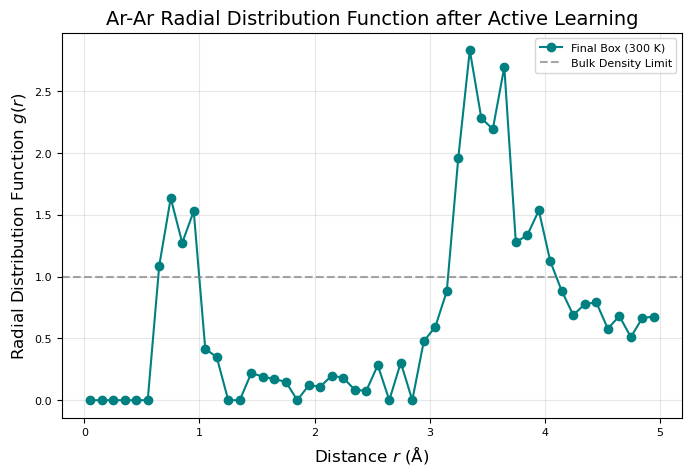

In [378]:
import numpy as np
import matplotlib.pyplot as plt
from ase.geometry.analysis import Analysis
import ase

# Define calculation parameters
box_lengths = test_atoms.get_cell_lengths_and_angles()[:3]
rmax = 5
nbins = 50

print(f"Calculating RDF up to a maximum distance of {rmax:.2f} Å...")

# Initialize the ASE Analysis tool
analyzer = Analysis([test_atoms])

# Compute the RDF
rdf = ase.geometry.rdf.get_rdf(test_atoms, rmax=rmax, nbins=nbins, elements=['Ar', 'Ar'])[0]

# Construct the x-axis (distance values) for plotting
dr = rmax / nbins
# The distance value for each bin is calculated at the center of the bin
distances = np.linspace(dr/2, rmax - dr/2, nbins)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(distances, rdf, marker='o', linestyle='-', color='teal', label='Final Box (300 K)')

# Add a horizontal line at g(r) = 1.0 (the theoretical limit for fluids at long distances)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Bulk Density Limit')

# Formatting
plt.xlabel('Distance $r$ (Å)', fontsize=12)
plt.ylabel('Radial Distribution Function $g(r)$', fontsize=12)
plt.title('Ar-Ar Radial Distribution Function after Active Learning', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Display the plot in Jupyter
plt.show()

### Let's do a potential energy scan. Maybe we can spot something weird here

Scanning dimer distances...


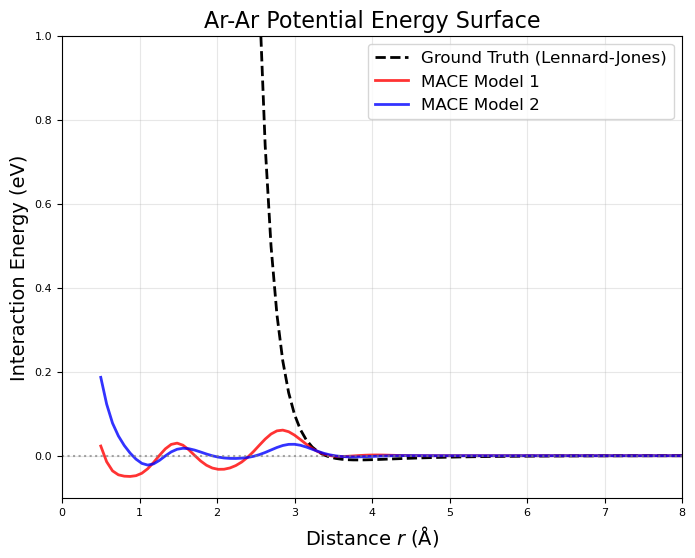

In [379]:
# 1. Initialize Calculators
# Use the ground truth LJ and your fine-tuned MACE model
lj_calc = LennardJones(epsilon=0.0103, sigma=3.40) 
mace_calc_1 = MACECalculator(model_paths="mace_model_1_compiled.model", device="cpu")
mace_calc_2 = MACECalculator(model_paths="mace_model_2_compiled.model", device="cpu")

# 2. Define the scan range (5.0 Å down to 0.5 Å)
distances = np.linspace(8.0, 0.5, 100)
lj_energies = []
mace_1_energies = []
mace_2_energies = []

# Create a simple two-atom Argon system in a large empty box
dimer = Atoms('Ar2', positions=[[0, 0, 0], [8.0, 0, 0]])
dimer.set_cell([10, 10, 10])

print("Scanning dimer distances...")

# 3. Run the scan
for d in distances:
    # Move the second atom
    dimer.set_positions([[0, 0, 0], [d, 0, 0]])
    
    # Get Lennard-Jones Energy
    dimer.calc = lj_calc
    lj_energies.append(dimer.get_potential_energy())
    
    # Get MACE Energy
    dimer.calc = mace_calc_1
    mace_1_energies.append(dimer.get_potential_energy())

    # Get MACE Energy
    dimer.calc = mace_calc_2
    mace_2_energies.append(dimer.get_potential_energy())

# Convert to numpy arrays for easier math
lj_energies = np.array(lj_energies)
mace_1_energies = np.array(mace_1_energies)
mace_2_energies = np.array(mace_2_energies)

# 4. Normalize the energies
# Align both curves so that the energy at 8.0 Å (index 0) is 0.0 eV.
# This gives us the pure interaction energy.
lj_interaction = lj_energies - lj_energies[0]
mace_1_interaction = mace_1_energies - mace_1_energies[0]
mace_2_interaction = mace_2_energies - mace_2_energies[0]

# 5. Plot the Potential Energy Surface
plt.figure(figsize=(8, 6))

plt.plot(distances, lj_interaction, 'k--', linewidth=2, label='Ground Truth (Lennard-Jones)')
plt.plot(distances, mace_1_interaction, 'r-', linewidth=2, alpha=0.8, label='MACE Model 1')
plt.plot(distances, mace_2_interaction, 'b-', linewidth=2, alpha=0.8, label='MACE Model 2')

# Add a horizontal line at E = 0 for reference
plt.axhline(0, color='gray', linestyle=':', alpha=0.7)

# Formatting
plt.xlabel('Distance $r$ (Å)', fontsize=14)
plt.ylabel('Interaction Energy (eV)', fontsize=14)
plt.title('Ar-Ar Potential Energy Surface', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# CRITICAL: The LJ repulsive wall goes to infinity. 
# We must cap the Y-axis so we can actually see the bottom of the well.
plt.ylim(-0.1, 1) 
plt.xlim(0.0, 8.0)

plt.show()

### Hmmm... wondering what is missing in the training set. Let's have a look at all the distances in the training set.

Analyzing 10 snapshots from the training set...


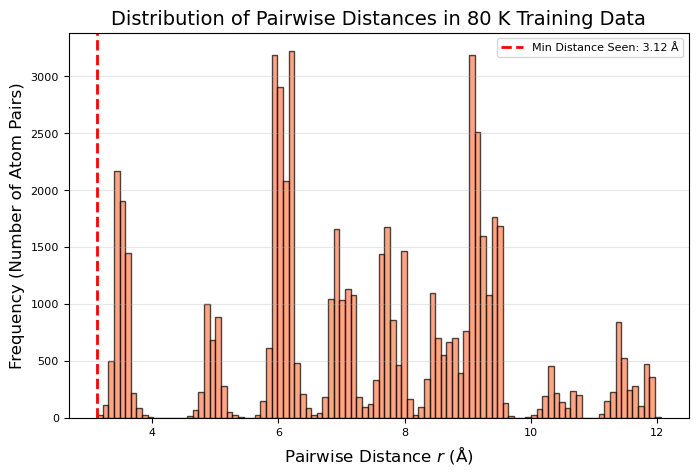

In [380]:
# We load the initial seed data to see what the first model learned
trajectory = read("seed_data_set_1.xyz", index=":")
print(f"Analyzing {len(trajectory)} snapshots from the training set...")

all_distances = []

# Extract pairwise distances from every snapshot
for atoms in trajectory:
    # Get the NxN distance matrix, applying minimum image convention (mic)
    dist_matrix = atoms.get_all_distances(mic=True)
    
    # We only want unique pairsd
    # Using np.triu_indices extracts only the upper triangle of the matrix.
    # k=1 offsets the extraction to exclude the diagonal zeros.
    upper_triangle_indices = np.triu_indices_from(dist_matrix, k=1)
    unique_distances = dist_matrix[upper_triangle_indices]
    
    all_distances.extend(unique_distances)

# Convert to numpy array for easier plotting/math
all_distances = np.array(all_distances)
min_seen_dist = np.min(all_distances)

# Plot the histogram
plt.figure(figsize=(8, 5))

# Use a high number of bins to see the structural peaks of the cold Argon
plt.hist(all_distances, bins=100, color='coral', edgecolor='black', alpha=0.7)

# Highlight the absolute minimum distance the model was exposed to
plt.axvline(min_seen_dist, color='red', linestyle='--', linewidth=2, 
            label=f'Min Distance Seen: {min_seen_dist:.2f} Å')

# Formatting
plt.xlabel('Pairwise Distance $r$ (Å)', fontsize=12)
plt.ylabel('Frequency (Number of Atom Pairs)', fontsize=12)
plt.title('Distribution of Pairwise Distances in 80 K Training Data', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

## Phase 3: Active Learning Loop

In [381]:
# precomputed trajectories that we can select from
possible_atoms = read("possible_configurations.xyz", index=":")

In [382]:
calc_1 = MACECalculator(model_paths="mace_model_1_compiled.model", device="cpu")
calc_2 = MACECalculator(model_paths="mace_model_2_compiled.model", device="cpu")

# Keep a "pristine" baseline copy of the crystal. 
# We will copy from this every time we restart so the box doesn't deform permanently.
base_atoms = bulk('Ar', crystalstructure='fcc', a=4.5, cubic=True).repeat((3, 3, 3))

temperature_K = 300 
target_configs = 5
found_atoms = []
variations = []

# Exception to break out of a SINGLE trajectory
class HighVarianceFound(Exception):
    pass

print(f"Starting Active Learning search for {target_configs} configurations...")

# Outer loop: Keep restarting MDs until we have 5 configurations
while len(found_atoms) < target_configs:
    print(f"\n--- Starting MD Search for Config {len(found_atoms) + 1}/{target_configs} ---")
    
    # 3. Reset the system: Copy baseline, apply a NEW rattle, and set velocities
    initial_atoms = base_atoms.copy()
    frame_rattle_seed = np.random.randint(0, 100000) 
    initial_atoms.rattle(stdev=0.1,seed=frame_rattle_seed)  # A fresh random displacement!
    initial_atoms.calc = calc_1
    MaxwellBoltzmannDistribution(initial_atoms, temperature_K=temperature_K)
    
    # Setup a fresh MD engine for this new trajectory
    dyn = Langevin(
        initial_atoms,
        timestep=1 * units.fs,
        temperature_K=temperature_K,
        friction=0.01
    )
    
    # Observer function
    def check_committee_variance():
        f1 = initial_atoms.get_forces() 
        
        current_at = initial_atoms.copy()
        current_at.calc = calc_2
        f2 = current_at.get_forces()
        
        force_variance = np.mean(np.linalg.norm(f1 - f2, axis=1))
        variations.append(force_variance)
        
        if force_variance > 0.1:
            print(f"High variance found: {force_variance:.3f} eV/Å. Triggering restart!")
            found_atoms.append(current_at) 
            # Break out of this specific dyn.run() 
            raise HighVarianceFound()

    dyn.attach(check_committee_variance, interval=5)
    
    # Run the MD's for active learning
    try:
        # Run a maximum of 1000 steps per rattle. 
        dyn.run(1000) 
        # If it gets here, it means 1000 steps passed WITHOUT finding high variance.
        # The loop will naturally continue, reset the box, and try a new rattle.
        print("MD reached 1000 steps without finding high variance. Restarting anyway.")
    except HighVarianceFound:
        # We caught our own exception. The while loop will now cycle and start fresh.
        pass

print(f"\n Successfully gathered {len(found_atoms)} independent configurations for Active Learning found")

Starting Active Learning search for 5 configurations...

--- Starting MD Search for Config 1/5 ---
High variance found: 0.195 eV/Å. Triggering restart!

--- Starting MD Search for Config 2/5 ---
High variance found: 0.187 eV/Å. Triggering restart!

--- Starting MD Search for Config 3/5 ---
High variance found: 0.177 eV/Å. Triggering restart!

--- Starting MD Search for Config 4/5 ---
High variance found: 0.208 eV/Å. Triggering restart!

--- Starting MD Search for Config 5/5 ---
High variance found: 0.199 eV/Å. Triggering restart!

 Successfully gathered 5 independent configurations for Active Learning found


In [383]:
# let's extend the training set with these 5 configurations that show high variance, and hope it improves the mlp!
ref_found_atoms = []
for at in found_atoms:
    truth_calc = LennardJones(epsilon=0.0103, sigma=3.40)
    at.calc = truth_calc
    at.get_potential_energy()
    ref_found_atoms.append(at)
old_training_data = read("seed_data_set_1.xyz", index=":")
extended_training_data = old_training_data + ref_found_atoms

write("new_training_data.xyz", extended_training_data)


!rm -rf checkpoints logs results

# Train Model 1. Using ! runs as a shell command instead
!rm -rf checkpoints logs results

!mace_run_train \
    --name="mace_model_1_stagetwo" \
    --train_file="new_training_data.xyz" \
    --energy_key="energy" \
    --forces_key="forces" \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="16x0e" \
    --batch_size=5 \
    --max_num_epochs=50 \
    --r_max=5.0 \
    --seed=42 \
    --swa \
    --device=cpu

!mace_run_train \
    --name="mace_model_2_stagetwo" \
    --train_file="new_training_data.xyz" \
    --energy_key="energy" \
    --forces_key="forces" \
    --E0s="average" \
    --model="MACE" \
    --num_interactions=2 \
    --max_ell=1 \
    --hidden_irreps="16x0e" \
    --batch_size=5 \
    --max_num_epochs=50 \
    --r_max=5.0 \
    --seed=30 \
    --swa \
    --device=cpu


/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
2026-06-03 03:11:40.909 INFO: ===========VERIFYING SETTINGS===========
2026-06-03 03:11:40.909 INFO: MACE version: 0.3.16
2026-06-03 03:11:40.910 INFO: Using CPU
2026-06-03 03:11:41.041 INFO: ===========LOADING INPUT DATA===========
2026-06-03 03:11:41.042 INFO: Using heads: ['Default']
2026-06-03 03:11:41.042 INFO: Using the key specifications to parse data:
2026-06-03 03:11:41.042 INFO: Default: KeySpecification(info_keys={'energy': 'energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head'

## Phase 4: Validation

/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/loic_du/micromamba/envs/mace-al/lib/python3.10/site-packages/mace/calculators/mace.py:226: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  torch.load(f=model_path, map_location=device)


Scanning dimer distances...


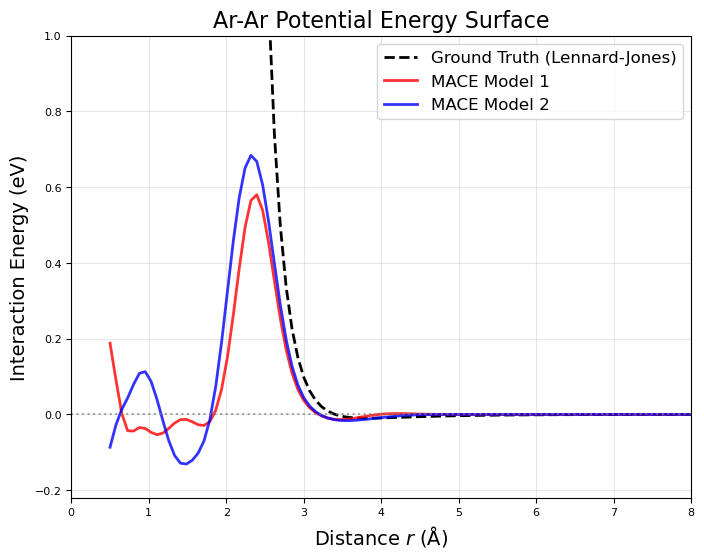

In [384]:
# 1. Initialize Calculators
# Use the ground truth LJ and your fine-tuned MACE model
lj_calc = LennardJones(epsilon=0.0103, sigma=3.40)
mace_calc_1 = MACECalculator(model_paths="mace_model_1_stagetwo_stagetwo_compiled.model", device="cpu")
mace_calc_2 = MACECalculator(model_paths="mace_model_2_stagetwo_stagetwo_compiled.model", device="cpu")

# 2. Define the scan range (5.0 Å down to 0.5 Å)
distances = np.linspace(8.0, 0.5, 100)
lj_energies = []
mace_1_energies = []
mace_2_energies = []

# Create a simple two-atom Argon system in a large empty box
dimer = Atoms('Ar2', positions=[[0, 0, 0], [8.0, 0, 0]])
dimer.set_cell([10, 10, 10])

print("Scanning dimer distances...")

# 3. Run the scan
for d in distances:
    # Move the second atom
    dimer.set_positions([[0, 0, 0], [d, 0, 0]])
    
    # Get Lennard-Jones Energy
    dimer.calc = lj_calc
    lj_energies.append(dimer.get_potential_energy())
    
    # Get MACE Energy
    dimer.calc = mace_calc_1
    mace_1_energies.append(dimer.get_potential_energy())

    # Get MACE Energy
    dimer.calc = mace_calc_2
    mace_2_energies.append(dimer.get_potential_energy())

# Convert to numpy arrays for easier math
lj_energies = np.array(lj_energies)
mace_1_energies = np.array(mace_1_energies)
mace_2_energies = np.array(mace_2_energies)

# 4. Normalize the energies
# Align both curves so that the energy at 8.0 Å (index 0) is 0.0 eV.
# This gives us the pure interaction energy.
lj_interaction = lj_energies - lj_energies[0]
mace_1_interaction = mace_1_energies - mace_1_energies[0]
mace_2_interaction = mace_2_energies - mace_2_energies[0]

# 5. Plot the Potential Energy Surface
plt.figure(figsize=(8, 6))

plt.plot(distances, lj_interaction, 'k--', linewidth=2, label='Ground Truth (Lennard-Jones)')
plt.plot(distances, mace_1_interaction, 'r-', linewidth=2, alpha=0.8, label='MACE Model 1')
plt.plot(distances, mace_2_interaction, 'b-', linewidth=2, alpha=0.8, label='MACE Model 2')

# Add a horizontal line at E = 0 for reference
plt.axhline(0, color='gray', linestyle=':', alpha=0.7)

# Formatting
plt.xlabel('Distance $r$ (Å)', fontsize=14)
plt.ylabel('Interaction Energy (eV)', fontsize=14)
plt.title('Ar-Ar Potential Energy Surface', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# CRITICAL: The LJ repulsive wall goes to infinity. 
# We must cap the Y-axis so we can actually see the bottom of the well.
plt.ylim(-0.22, 1) 
plt.xlim(0.0, 8.0)

plt.show()